### Forward simulation: two-accumulator and multi-stage race model

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from cssm import race_multistage
from ssms.basic_simulators.race_math import big_F, small_f

RANDOM_STATE = 20260820
OMISSION = -999.0
dt = 1e-3
T = 1.5

#### 0.1 One-stage race

In [2]:
mu = np.array([0.90, 0.55])
sigma = np.array([1.0, 1.0])
a = np.array([1.0, 1.0])
b = np.array([0.0, 0.0])
x0 = np.array([0.0, 0.0])

one_stage_arrays = {
    'mu_array': mu[None, :, None],
    'sigma_array': sigma[None, :, None],
    'node_array': np.zeros((1, 2, 1)),
    'd_array': np.ones((1, 2), dtype=np.int32),
    'upper_intercept_array': a[None, :, None],
    'upper_slope_array': b[None, :, None],
    'x0_array': x0[None, :],
}

out = race_multistage(
    **one_stage_arrays, n_samples=30_000, delta_t=dt, max_t=T, random_state=RANDOM_STATE,
)
rt = out['rts'].reshape(-1)
choice = out['choices'].reshape(-1)
responded = rt != OMISSION

for i in range(2):
    print(f'P(choice = {i}): {np.mean(responded & (choice == i)):.4f}')
print(f'P(omission): {np.mean(~responded):.4f}')

P(choice = 0): 0.5360
P(choice = 1): 0.3823
P(omission): 0.0816


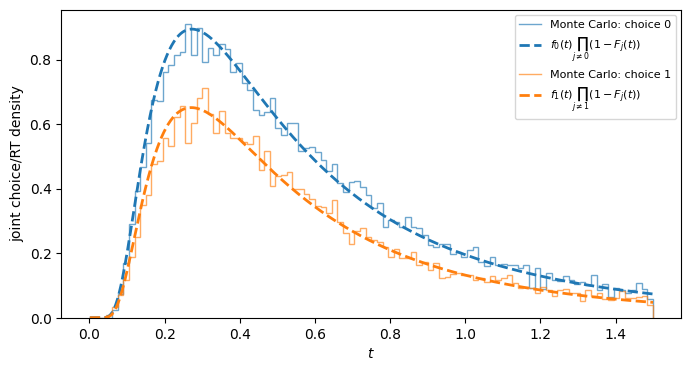

choice 0: empirical=0.5360, analytic=0.5398
choice 1: empirical=0.3823, analytic=0.3824


In [3]:
ts = np.linspace(1e-3, T, 1_000)
f = np.array([small_f(ts, mu[i], sigma[i], a[i], b[i], T, x0[i]) for i in range(2)])
F = np.array([big_F(ts, mu[i], sigma[i], a[i], b[i], T, x0[i]) for i in range(2)])
race_density = np.array([f[i] * (1.0 - F[1 - i]) for i in range(2)])

bins = np.linspace(0.0, T, 101)
width = bins[1] - bins[0]
fig, ax = plt.subplots(figsize=(8, 4))
for i, color in enumerate(['tab:blue', 'tab:orange']):
    rts_i = rt[responded & (choice == i)]
    counts, _ = np.histogram(rts_i, bins=bins)
    ax.stairs(counts / (rt.size * width), bins, color=color, alpha=0.65, label=fr'Monte Carlo: choice {i}')
    ax.plot(ts, race_density[i], color=color, linestyle='--', linewidth=2, label=fr'$f_{i}(t)\prod_{{j\ne {i}}}(1-F_j(t))$')
ax.set(xlabel=r'$t$', ylabel='joint choice/RT density')
ax.legend(fontsize=8)
plt.show()

for i in range(2):
    analytic_probability = np.trapezoid(race_density[i], ts)
    empirical_probability = np.mean(responded & (choice == i))
    print(f'choice {i}: empirical={empirical_probability:.4f}, analytic={analytic_probability:.4f}')

#### 0.2 Multi-stage race

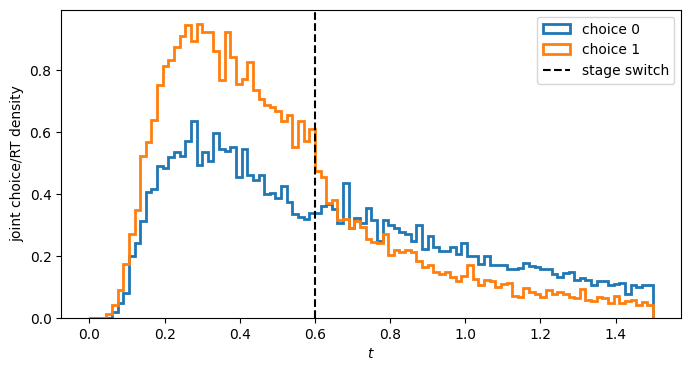

P(choice = 0): 0.4109
P(choice = 1): 0.5034
P(omission): 0.0857


In [4]:
# Both accumulators switch drift at t = 0.60.
multi_stage_arrays = {
    'mu_array': np.array([[[0.45, 1.10], [0.95, 0.30]]]),
    'sigma_array': np.ones((1, 2, 2)),
    'node_array': np.array([[[0.0, 0.60], [0.0, 0.60]]]),
    'd_array': np.array([[2, 2]], dtype=np.int32),
    'upper_intercept_array': np.ones((1, 2, 2)),
    'upper_slope_array': np.zeros((1, 2, 2)),
    'x0_array': np.zeros((1, 2)),
}

out_stage = race_multistage(
    **multi_stage_arrays, n_samples=30_000, delta_t=dt, max_t=T, random_state=RANDOM_STATE,
)
rt_stage = out_stage['rts'].reshape(-1)
choice_stage = out_stage['choices'].reshape(-1)
responded_stage = rt_stage != OMISSION

fig, ax = plt.subplots(figsize=(8, 4))
for i, color in enumerate(['tab:blue', 'tab:orange']):
    ax.hist(rt_stage[responded_stage & (choice_stage == i)], bins=bins, density=False,
            weights=np.full(np.sum(responded_stage & (choice_stage == i)), 1.0 / (rt_stage.size * width)),
            histtype='step', linewidth=2, color=color, label=f'choice {i}')
ax.axvline(0.60, color='black', linestyle='--', label='stage switch')
ax.set(xlabel=r'$t$', ylabel='joint choice/RT density')
ax.legend()
plt.show()

for i in range(2):
    print(f'P(choice = {i}): {np.mean(responded_stage & (choice_stage == i)):.4f}')
print(f'P(omission): {np.mean(~responded_stage):.4f}')